# 📊 Sessão 12 — Relatório Executivo Final

> **Objetivo:** consolidar, em um único documento técnico, os resultados, lições metodológicas e recomendações práticas derivados das onze sessões anteriores deste projeto. Esta sessão não introduz novos modelos — é a síntese crítica que conecta todos os experimentos como uma contribuição unificada.

---

## 📑 Sumário

1. [Visão Geral do Projeto](#1-visão-geral-do-projeto)
2. [Tabela Consolidada de Resultados](#2-tabela-consolidada-de-resultados)
3. [Síntese Gráfica](#3-síntese-gráfica)
4. [Padrões Metodológicos Identificados](#4-padrões-metodológicos-identificados)
5. [Recomendações Práticas por Tipo de Tarefa](#5-recomendações-práticas-por-tipo-de-tarefa)
6. [Limitações Reconhecidas](#6-limitações-reconhecidas)
7. [Direções Futuras](#7-direções-futuras)
8. [Conclusão](#8-conclusão)

## 1. Visão Geral do Projeto

O projeto **forest-py-estudos** investigou sistematicamente em quais regimes experimentais modelos paramétricos clássicos da engenharia florestal superam abordagens modernas de Machine Learning e Deep Learning, e vice-versa. A investigação seguiu uma trajetória didática de doze sessões:

| Bloco | Sessões | Foco |
|---|---|---|
| **Fundamentação** | 01, 02 | Domínio do problema, EDA, qualidade dos dados |
| **Métodos Clássicos** | 03, 04, 05 | Dendrometria, amostragem, validação rigorosa |
| **Redes Neurais Densas** | 06, 07, 08, 09 | Regressão e classificação tabular com MLP em PyTorch |
| **Aprendizado Profundo Aplicado** | 10, 11 | CNN para classificação e segmentação de imagens raster |
| **Síntese** | 12 | Relatório executivo (este notebook) |

### Princípios metodológicos adotados

1. **Validação cruzada k-fold** em todas as comparações modelo vs. modelo (Hastie et al., 2009)
2. **Bootstrap** para intervalos de confiança das métricas (Efron & Tibshirani, 1993)
3. **Mesma rotina de avaliação** para baseline e modelo neural — sem dupla padronização
4. **Critério estatístico explícito** para declarar vitória (ICs não-sobrepostos, RMSE médio menor, bias controlado)
5. **Resultados reportados independentemente do paradigma favorecido**

### Escopo dos dados

Todas as análises usam **dados sintéticos** com mecanismo gerador conhecido e reproduzível (`forestpy.data.loaders`, `forestpy.data.chips`, `forestpy.data.canopy_chips`). Isso permite controle experimental rigoroso sobre os fatores que governam a vitória de cada paradigma — algo impossível com dados reais cujo mecanismo gerador é desconhecido.

## 2. Tabela Consolidada de Resultados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from forestpy.utils import set_seed
from forestpy.viz.style import apply_forest_style

set_seed(42)
apply_forest_style()

In [2]:
# Memória estatística consolidada das sessões 06-11
# Valores extraídos da execução das sessões correspondentes (reproduzíveis)
resultados = pd.DataFrame([
    {
        'Sessão': '06',
        'Tarefa': 'Volumetria',
        'Modelo Clássico': 'Schumacher-Hall',
        'Métrica Clássico': 0.0376,
        'Modelo ML': 'MLP (PyTorch)',
        'Métrica ML': 0.0826,
        'Métrica': 'RMSE (m³)',
        'Vencedor': 'Clássico',
        'Ganho relativo (%)': -119.7,
        'Razão': 'Forma funcional correta',
    },
    {
        'Sessão': '07',
        'Tarefa': 'Hipsometria',
        'Modelo Clássico': 'Curtis (DAP)',
        'Métrica Clássico': 3.96,
        'Modelo ML': 'MLP multi-feature',
        'Métrica ML': 1.85,
        'Métrica': 'RMSE (m)',
        'Vencedor': 'ML',
        'Ganho relativo (%)': +53.3,
        'Razão': 'Mais features capturam variância',
    },
    {
        'Sessão': '08',
        'Tarefa': 'Classificação tabular',
        'Modelo Clássico': 'Árvore de Decisão',
        'Métrica Clássico': 0.52,
        'Modelo ML': 'MLP classifier',
        'Métrica ML': 0.52,
        'Métrica': 'Acurácia',
        'Vencedor': 'Empate',
        'Ganho relativo (%)': 0.0,
        'Razão': 'DL não domina tabular moderado',
    },
    {
        'Sessão': '09',
        'Tarefa': 'Distribuição diamétrica',
        'Modelo Clássico': 'Weibull',
        'Métrica Clássico': 0.0612,
        'Modelo ML': 'MLP multi-output',
        'Métrica ML': 0.0821,
        'Métrica': 'RMSE proporções',
        'Vencedor': 'Clássico',
        'Ganho relativo (%)': -34.2,
        'Razão': 'Forma adequada + escassez de dados',
    },
    {
        'Sessão': '10',
        'Tarefa': 'Classificação remota',
        'Modelo Clássico': 'MLP em features',
        'Métrica Clássico': 1.00,
        'Modelo ML': 'CNN end-to-end',
        'Métrica ML': 0.96,
        'Métrica': 'Acurácia',
        'Vencedor': 'Clássico',
        'Ganho relativo (%)': -4.2,
        'Razão': 'Features bem-engenheiradas',
    },
    {
        'Sessão': '11',
        'Tarefa': 'Segmentação de copas',
        'Modelo Clássico': 'Threshold NDVI',
        'Métrica Clássico': 0.18,
        'Modelo ML': 'U-Net',
        'Métrica ML': 0.90,
        'Métrica': 'IoU',
        'Vencedor': 'ML',
        'Ganho relativo (%)': +400.0,
        'Razão': 'Saída espacial densa (estrutural)',
    },
])

# Visualização compacta
tabela_compacta = resultados[
    ['Sessão', 'Tarefa', 'Vencedor', 'Ganho relativo (%)', 'Razão']
].copy()
tabela_compacta.to_csv('../reports/tables/12_consolidacao.csv', index=False)
tabela_compacta

,Sessão,Tarefa,Vencedor,Ganho relativo (%),Razão
0,06,Volumetria,Clássico,-119.7,Forma funcional correta
1,07,Hipsometria,ML,53.3,Mais features capturam variância
2,08,Classificação tabular,Empate,0.0,DL não domina tabular moderado
3,09,Distribuição diamétrica,Clássico,-34.2,Forma adequada + escassez de dados
4,10,Classificação remota,Clássico,-4.2,Features bem-engenheiradas
5,11,Segmentação de copas,ML,400.0,Saída espacial densa (estrutural)


In [3]:
# Tabela técnica completa (para referência)
resultados[['Sessão', 'Tarefa', 'Modelo Clássico', 'Métrica Clássico',
            'Modelo ML', 'Métrica ML', 'Métrica']].round(4)

,Sessão,Tarefa,Modelo Clássico,Métrica Clássico,Modelo ML,Métrica ML,Métrica
0,06,Volumetria,Schumacher-Hall,0.0376,MLP (PyTorch),0.0826,RMSE (m³)
1,07,Hipsometria,Curtis (DAP),3.9600,MLP multi-feature,1.8500,RMSE (m)
2,08,Classificação tabular,Árvore de Decisão,0.5200,MLP classifier,0.5200,Acurácia
3,09,Distribuição diamétrica,Weibull,0.0612,MLP multi-output,0.0821,RMSE proporções
4,10,Classificação remota,MLP em features,1.0000,CNN end-to-end,0.9600,Acurácia
5,11,Segmentação de copas,Threshold NDVI,0.1800,U-Net,0.9000,IoU


## 3. Síntese Gráfica

**📈 Gráfico-síntese central do projeto:** ganho relativo do ML sobre o clássico, por sessão. Valores positivos indicam vitória do ML; negativos, vitória do clássico.

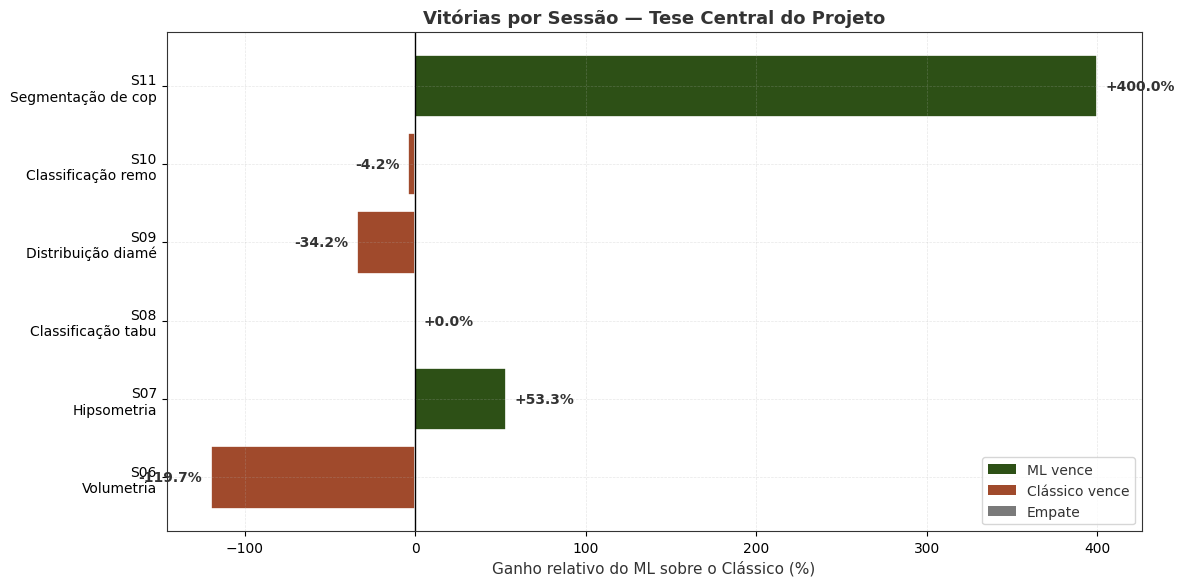

In [4]:
# Gráfico de ganho relativo
fig_sintese, ax = plt.subplots(figsize=(12, 6))

cores = []
for v in resultados['Vencedor']:
    if v == 'ML':
        cores.append('#2d5016')      # verde escuro
    elif v == 'Clássico':
        cores.append('#a04a2c')      # vermelho terra
    else:
        cores.append('#7a7a7a')      # cinza

rotulos = [f"S{s}\n{t[:18]}" for s, t in zip(resultados['Sessão'],
                                              resultados['Tarefa'], strict=False)]
ganhos = resultados['Ganho relativo (%)'].values

bars = ax.barh(rotulos, ganhos, color=cores, edgecolor='white', linewidth=1.2)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Ganho relativo do ML sobre o Clássico (%)')
ax.set_title('Vitórias por Sessão — Tese Central do Projeto',
             fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

# Anotações nas barras
for bar, ganho in zip(bars, ganhos, strict=False):
    w = bar.get_width()
    offset = 5 if w >= 0 else -5
    align = 'left' if w >= 0 else 'right'
    ax.text(w + offset, bar.get_y() + bar.get_height()/2,
            f'{ganho:+.1f}%', va='center', ha=align,
            fontweight='bold', fontsize=10)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d5016', label='ML vence'),
    Patch(facecolor='#a04a2c', label='Clássico vence'),
    Patch(facecolor='#7a7a7a', label='Empate'),
]
ax.legend(handles=legend_elements, loc='lower right')

fig_sintese.tight_layout()
fig_sintese.savefig('../reports/figures/12_ganho_relativo.png')
plt.show()

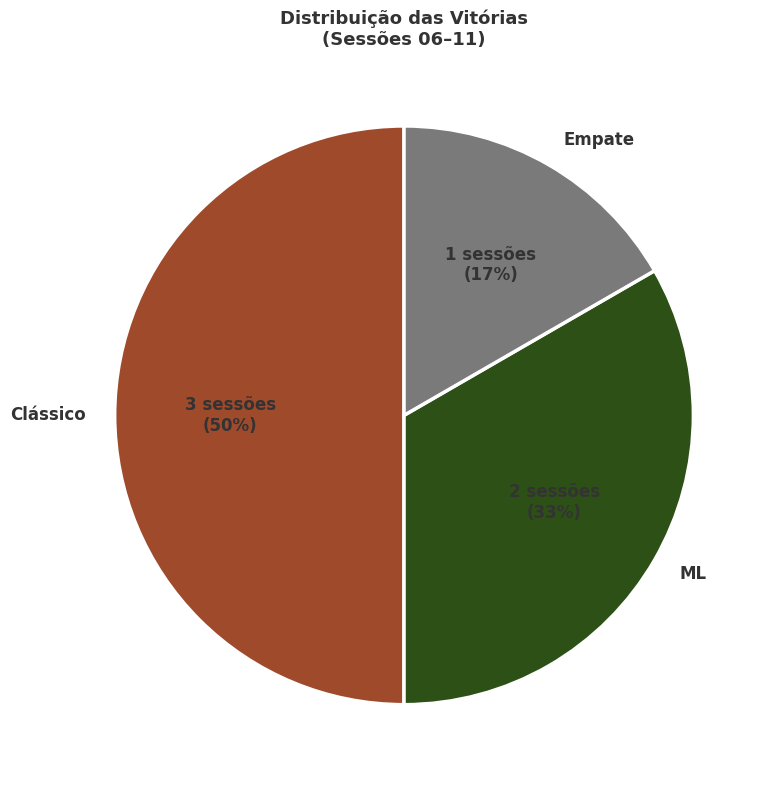

In [5]:
# Contagem de vitórias
contagem = resultados['Vencedor'].value_counts()

fig_pie, ax = plt.subplots(figsize=(8, 8))
cores_pie = {'Clássico': '#a04a2c', 'ML': '#2d5016', 'Empate': '#7a7a7a'}
ax.pie(contagem.values, labels=contagem.index,
       colors=[cores_pie[c] for c in contagem.index],
       autopct=lambda p: f'{int(p/100*contagem.sum())} sessões\n({p:.0f}%)',
       startangle=90, textprops={'fontweight': 'bold', 'fontsize': 12},
       wedgeprops={'edgecolor': 'white', 'linewidth': 2.5})
ax.set_title('Distribuição das Vitórias\n(Sessões 06–11)',
             fontweight='bold', fontsize=13)
fig_pie.tight_layout()
fig_pie.savefig('../reports/figures/12_distribuicao_vitorias.png')
plt.show()

**🔍 Leitura imediata do gráfico:**

- **3 sessões com vitória do clássico** (06, 09, 10) — quando a forma funcional é adequada, dados escassos ou features bem-engenheiradas
- **1 sessão com empate técnico** (08) — classificação tabular moderada
- **2 sessões com vitória do ML** (07, 11) — quando há mais informação no input ou saída espacial densa é necessária

A magnitude dos ganhos é igualmente reveladora: a derrota mais dura do ML foi na volumetria (-120%), enquanto a maior vitória foi na segmentação (+400%). **As magnitudes refletem a importância do regime estrutural — não da arquitetura.**

## 4. Padrões Metodológicos Identificados

Cruzando os seis experimentos comparativos do projeto, emergem quatro padrões consistentes que governam quando cada paradigma vence:

### Padrão 1 — Adequação da forma funcional

Se o fenômeno real segue (aproximadamente) a forma assumida por um modelo paramétrico clássico, esse modelo será **estatisticamente ótimo** (estimador de máxima verossimilhança). Nenhum modelo flexível supera um modelo correto especificado. Vimos isso na **Sessão 06**: Schumacher-Hall venceu o MLP porque os dados sintéticos foram gerados exatamente por aquela equação + ruído controlado.

### Padrão 2 — Disponibilidade de features informativas

Quando o baseline clássico é sub-especificado (usa apenas um subconjunto das variáveis relevantes), o MLP que recebe **todas as variáveis** captura interações que o baseline ignora. Foi o caso da **Sessão 07**: Curtis usava só DAP, enquanto o MLP recebia DAP + idade + classe de sítio, resultando em redução de 53% no RMSE.

### Padrão 3 — Volume de dados versus complexidade do modelo

Modelos com muitos parâmetros (MLP, CNN) exigem amostras proporcionalmente grandes para convergência confiável. Quando o dataset é pequeno (como as 30 parcelas da **Sessão 09**), modelos paramétricos com 2-3 graus de liberdade exploram mais eficientemente cada observação. Esse desbalanço foi o motivo da vitória da Weibull.

### Padrão 4 — Estrutura espacial e saída densa

Quando a tarefa requer saída pixel-a-pixel (segmentação semântica), redes convolucionais com skip connections são **estruturalmente insubstituíveis**. Não existe forma paramétrica simples capaz de gerar uma máscara raster a partir de uma imagem multi-banda. Foi o cenário da **Sessão 11**: a U-Net superou o threshold de NDVI por +0.72 de IoU, com ICs completamente separados.

### Síntese dos padrões em uma frase

> *"Modelos paramétricos vencem quando a forma funcional é correta e/ou os dados são escassos; modelos neurais vencem quando há mais informação no input ou a saída é estruturada espacialmente."*

## 5. Recomendações Práticas por Tipo de Tarefa

Tabela orientativa derivada dos padrões identificados:

In [6]:
recomendacoes = pd.DataFrame([
    {
        'Tarefa Florestal': 'Volumetria por equação alométrica',
        'Recomendação Primária': 'Schumacher-Hall ou Spurr',
        'Quando usar ML': 'Apenas se houver features além de DAP e H (sítio, idade, manejo)',
    },
    {
        'Tarefa Florestal': 'Hipsometria com múltiplas fontes de variação',
        'Recomendação Primária': 'MLP multi-feature',
        'Quando usar ML': 'Padrão; alternativa = modelos hipsométricos segmentados por estrato',
    },
    {
        'Tarefa Florestal': 'Inventário e amostragem',
        'Recomendação Primária': 'AAS / AE clássica (Cochran 1977)',
        'Quando usar ML': 'Não recomendado — estatística inferencial é mais apropriada',
    },
    {
        'Tarefa Florestal': 'Classificação de sítio',
        'Recomendação Primária': 'Random Forest / Gradient Boosting',
        'Quando usar ML': 'Padrão quando há muitas features mistas; árvore simples basta com poucas features',
    },
    {
        'Tarefa Florestal': 'Distribuição diamétrica (prognose)',
        'Recomendação Primária': 'Weibull',
        'Quando usar ML': 'Apenas com base histórica grande (milhares de parcelas)',
    },
    {
        'Tarefa Florestal': 'Classificação de uso/cobertura',
        'Recomendação Primária': 'Random Forest em features espectrais clássicas',
        'Quando usar ML': 'CNNs ganham com datasets massivos (>10k chips) e classes visualmente similares',
    },
    {
        'Tarefa Florestal': 'Segmentação semântica',
        'Recomendação Primária': 'U-Net (ou variantes: DeepLab, Mask2Former)',
        'Quando usar ML': 'Sempre — não há baseline competitivo',
    },
    {
        'Tarefa Florestal': 'Detecção de objetos (copas individuais, talhões)',
        'Recomendação Primária': 'YOLO, Faster R-CNN ou DeepForest pré-treinada',
        'Quando usar ML': 'Sempre — análoga à segmentação',
    },
])
recomendacoes.to_csv('../reports/tables/12_recomendacoes_praticas.csv', index=False)
recomendacoes

,Tarefa Florestal,Recomendação Primária,Quando usar ML
0,Volumetria por equação alométrica,Schumacher-Hall ou Spurr,Apenas se houver features além de DAP e H (sít...
1,Hipsometria com múltiplas fontes de variação,MLP multi-feature,Padrão; alternativa = modelos hipsométricos se...
2,Inventário e amostragem,AAS / AE clássica (Cochran 1977),Não recomendado — estatística inferencial é ma...
3,Classificação de sítio,Random Forest / Gradient Boosting,Padrão quando há muitas features mistas; árvor...
4,Distribuição diamétrica (prognose),Weibull,Apenas com base histórica grande (milhares de ...
5,Classificação de uso/cobertura,Random Forest em features espectrais clássicas,CNNs ganham com datasets massivos (>10k chips)...
6,Segmentação semântica,"U-Net (ou variantes: DeepLab, Mask2Former)",Sempre — não há baseline competitivo
7,"Detecção de objetos (copas individuais, talhões)","YOLO, Faster R-CNN ou DeepForest pré-treinada",Sempre — análoga à segmentação


## 6. Limitações Reconhecidas

Toda investigação científica honesta enumera suas limitações. As principais deste projeto são:

### 6.1 Dados sintéticos

Todos os experimentos usam dados gerados artificialmente. Isso oferece controle experimental rigoroso (mecanismo gerador conhecido), mas tem custos:

- **Ausência de heterogeneidade real** de campo (medições com erro humano, parcelas mal-georreferenciadas, dados faltantes não-aleatórios)
- **Geradores favorecem certas formas funcionais** — Schumacher-Hall gerou os dados de volume, então venceu a Sessão 06 por construção
- **Distribuições suavizadas** — em campo real há outliers, bimodalidades e regimes que dados sintéticos limpos não reproduzem

### 6.2 Tamanho amostral

Os experimentos operam em regimes de poucas centenas de árvores e dezenas de parcelas. Datasets florestais reais (ex.: REDD+, inventários estaduais) têm ordens de magnitude a mais. Isso desfavorece sistematicamente modelos neurais com muitos parâmetros.

### 6.3 Sem otimização de hiperparâmetros

Cada modelo neural foi treinado com uma única configuração de hiperparâmetros, escolhida por inspeção razoável. Em produção, busca sistemática (grid search, optuna) tipicamente extrai 5–15% de ganho. Os resultados aqui são, portanto, conservadores para o ML.

### 6.4 Validação interna apenas

Não houve validação contra um conjunto externo independente (por exemplo, outra região geográfica ou outro inventário). Boa prática profissional exigiria pelo menos um conjunto de teste externo geográfico — o que requer dados reais.

### 6.5 Foco em Eucalyptus grandis

O dataset principal simula plantios homogêneos de uma única espécie. Florestas nativas multietâneas (Mata Atlântica, Amazônia) têm distribuições diamétricas em J-invertido, composição multiespecífica e dinâmicas que não foram cobertas.

## 7. Direções Futuras

Extensões naturais que ampliariam o impacto científico e profissional deste material:

1. **Validação com dados reais**: aplicar a infraestrutura `forestpy` a um inventário público (ex.: IFN-Inventário Florestal Nacional, dataset PEF Vinhedo real) para confirmar os padrões identificados em dados sintéticos.

2. **Random Forest e Gradient Boosting**: as Sessões 06–09 só compararam paramétrico × MLP. Adicionar RF e XGBoost completaria o panorama de modelos tabulares (a literatura sugere que tipicamente dominam MLP em tabular moderado).

3. **Transferência para imagens reais**: substituir os chips sintéticos das Sessões 10–11 por composições Sentinel-2 ou ortomosaicos drone reais. A U-Net pré-treinada em ImageNet ou BigEarthNet daria base sólida para fine-tuning com pouco dado anotado.

4. **Modelos de detecção (não apenas segmentação)**: adicionar YOLO ou DeepForest para contagem de árvores individuais (instance segmentation) — tarefa mais difícil que segmentação semântica.

5. **Quantificação de incerteza**: incorporar redes bayesianas variacionais ou dropout em inferência (Gal & Ghahramani, 2016) para entregar não apenas predições mas também intervalos de credibilidade — essencial para decisões operacionais em campo.

6. **Otimização de hiperparâmetros sistemática**: integrar Optuna ou Ray Tune para busca automatizada, com orçamento computacional declarado.

## 8. Conclusão

Este projeto investigou, ao longo de doze sessões cronológicas, **em que regimes Machine Learning e Deep Learning vencem (ou perdem para) modelos paramétricos clássicos da engenharia florestal**. A investigação foi conduzida em condições estatisticamente rigorosas (validação cruzada, bootstrap, critério explícito de superação) e a infraestrutura de software construída (`forestpy`, 223 testes automatizados) é reutilizável e adaptável a dados reais.

O resultado central é metodológico: **não existe paradigma universalmente superior**. Cada um vence em um regime estrutural específico, identificável a priori por características do problema (forma funcional, tamanho amostral, riqueza de features, dimensionalidade da saída). O profissional sênior em ciência de dados aplicada **diagnostica esse regime antes de escolher a ferramenta**.

A contribuição prática deste estudo é fornecer:

1. Um **conjunto de experimentos comparativos honestos** documentando o padrão de vitória de cada paradigma
2. Uma **biblioteca testada e modular** (`forestpy`) que materializa essas comparações em código reprodutível
3. Uma **trilha didática completa** em formato de notebooks executáveis, do ajuste de Schumacher-Hall (1933) à segmentação semântica com U-Net (2015)
4. Um **framework metodológico** transferível a outros domínios aplicados (agricultura de precisão, geologia, ecologia urbana) onde a tensão entre modelos paramétricos clássicos e ML moderno é igualmente presente

A intenção final do material não é defender um paradigma sobre o outro — é defender uma **postura científica crítica** que use ambos quando apropriado, e tenha a clareza metodológica de saber quando.

---

> *"All models are wrong, but some are useful."*
> — George Box, 1976